In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import utils
from scipy import stats

## 宣告function

In [8]:
def find_row_col(x):
    x_r = round(np.sqrt(x))
    y_1 = 0
    y_2 = 0
    for i in np.arange(x_r+1,0, -1):
        if x%i == 0:
            y_1 = i
            y_2 = x//y_1
            break
            
    if y_1 ==1 or y_2==1:
        j = x_r
        while j**2 <x:
            j = j+1
        y_1 = j
        y_2 = j
    return y_1,y_2

def corr(x,y,r):
    H = False
    correlation_coefficient, p_value = stats.spearmanr(x, y)
    rr = correlation_coefficient**2
    
    # print(f'皮爾遜相關係數(r):{correlation_coefficient:.4f}')
    # print(f'P-value:{p_value:.4f}')
    # print(f'決定係數(R^2):{rr:.4f}')
    
    alpha = 0.01

    if p_value<alpha:
        # print("\n結論：結果具有統計學意義 (P值 < 0.05)。")
        # print("我們可以拒絕母體不相關的虛無假說，認為測速照相密度與車禍發生密度存在顯著的線性關係。")
        H = True
    # else:
        # print("\n結論：結果不具有統計學意義。")
        # print("無法證明母體中存在線性關係。")
    # print('=========================================')
    # print(f"解釋變異量：測速照相密度可以解釋車禍發生密度約 {rr*100:.2f}% 的變異。")
    # print('=================================================================================')
    l = [correlation_coefficient,p_value,rr]
    return l,H

def compare_correlations(r1, n1, r2, n2):
    # r1, r2: 兩組的相關係數
    # n1, n2: 兩組的樣本數 (這很重要，樣本越大越容易顯著)
    
    # Fisher Z 轉換
    z1 = 0.5 * np.log((1 + r1) / (1 - r1))
    z2 = 0.5 * np.log((1 + r2) / (1 - r2))
    
    # 計算標準誤
    se_diff = np.sqrt(1.06/(n1-3) + 1.06/(n2-3))
    
    # 計算 Z 分數
    z_score = (z1 - z2) / se_diff
    
    # 算出 P-value (雙尾檢定)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    
    return p_value

## 基本變數宣告

In [3]:
min_radius = 500
max_radius = 10000
gap = 2000
radius = np.arange(min_radius,max_radius+1,gap)
row,col = find_row_col(len(radius))
COUNTYNAME = {'臺北市':'Taipei', '新北市':'New_Taipei'}
COUNTY = ['臺北市', '新北市']
print(row,col)

2 5


## 讀入車禍資料

In [13]:
accident = pd.read_csv(f'./accident/Taipei_NewTaipei_accident.csv', sep = ',', skipinitialspace=True)
accident = gpd.GeoDataFrame(accident, geometry=gpd.points_from_xy(accident['經度'], accident['緯度']), crs="EPSG:4326")
accident = accident.to_crs(epsg=3826)
accident['發生日期'] = pd.to_datetime(accident['發生日期']).copy()
accident

,發生年度,發生月份,發生日期,發生地點,經度,緯度,geometry
0,2025,1.0,1970-01-01 00:00:00.020250101,基隆市安樂區安樂路一段95號前0.0公尺,121.733651,25.128823,POINT (323978.629 2780247.494)
1,2025,1.0,1970-01-01 00:00:00.020250101,基隆市安樂區安樂路一段95號前0.0公尺,121.733651,25.128823,POINT (323978.629 2780247.494)
2,2025,1.0,1970-01-01 00:00:00.020250101,桃園市八德區長興一路附近 / 桃園市八德區長興二路附近,121.280105,24.933127,POINT (278289.155 2758399.773)
3,2025,1.0,1970-01-01 00:00:00.020250101,桃園市八德區長興一路附近 / 桃園市八德區長興二路附近,121.280105,24.933127,POINT (278289.155 2758399.773)
4,2025,1.0,1970-01-01 00:00:00.020250101,桃園市八德區長興一路附近 / 桃園市八德區長興二路附近,121.280105,24.933127,POINT (278289.155 2758399.773)
...,...,...,...,...,...,...,...
897243,2025,1.0,1970-01-01 00:00:00.020250131,高雄市楠梓區惠心街 / 高雄市楠梓區青埔街,120.322294,22.729380,POINT (180387.942 2514476.163)
897244,2025,1.0,1970-01-01 00:00:00.020250131,高雄市楠梓區德民路 / 高雄市楠梓區德賢路,120.304672,22.726881,POINT (178576.501 2514207.817)
897245,2025,1.0,1970-01-01 00:00:00.020250131,高雄市楠梓區德民路 / 高雄市楠梓區德賢路,120.304672,22.726881,POINT (178576.501 2514207.817)
897246,資料提供日期：114年11月01日,NaN,NaT,NaN,NaN,NaN,POINT (NaN NaN)


## 分別計算

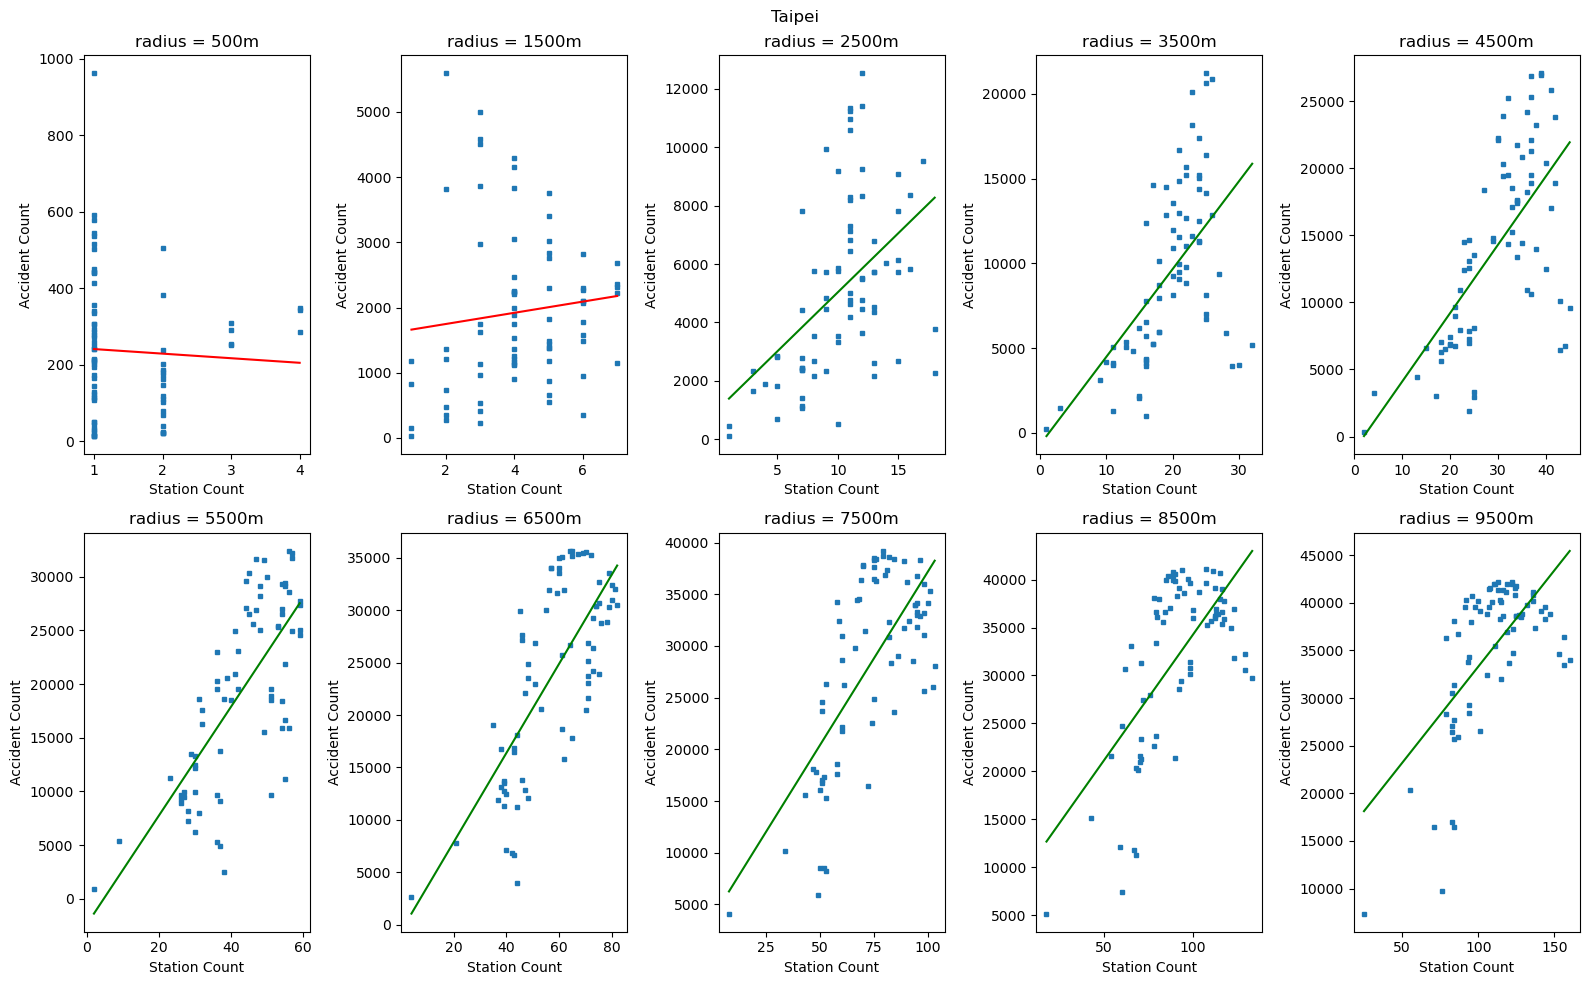

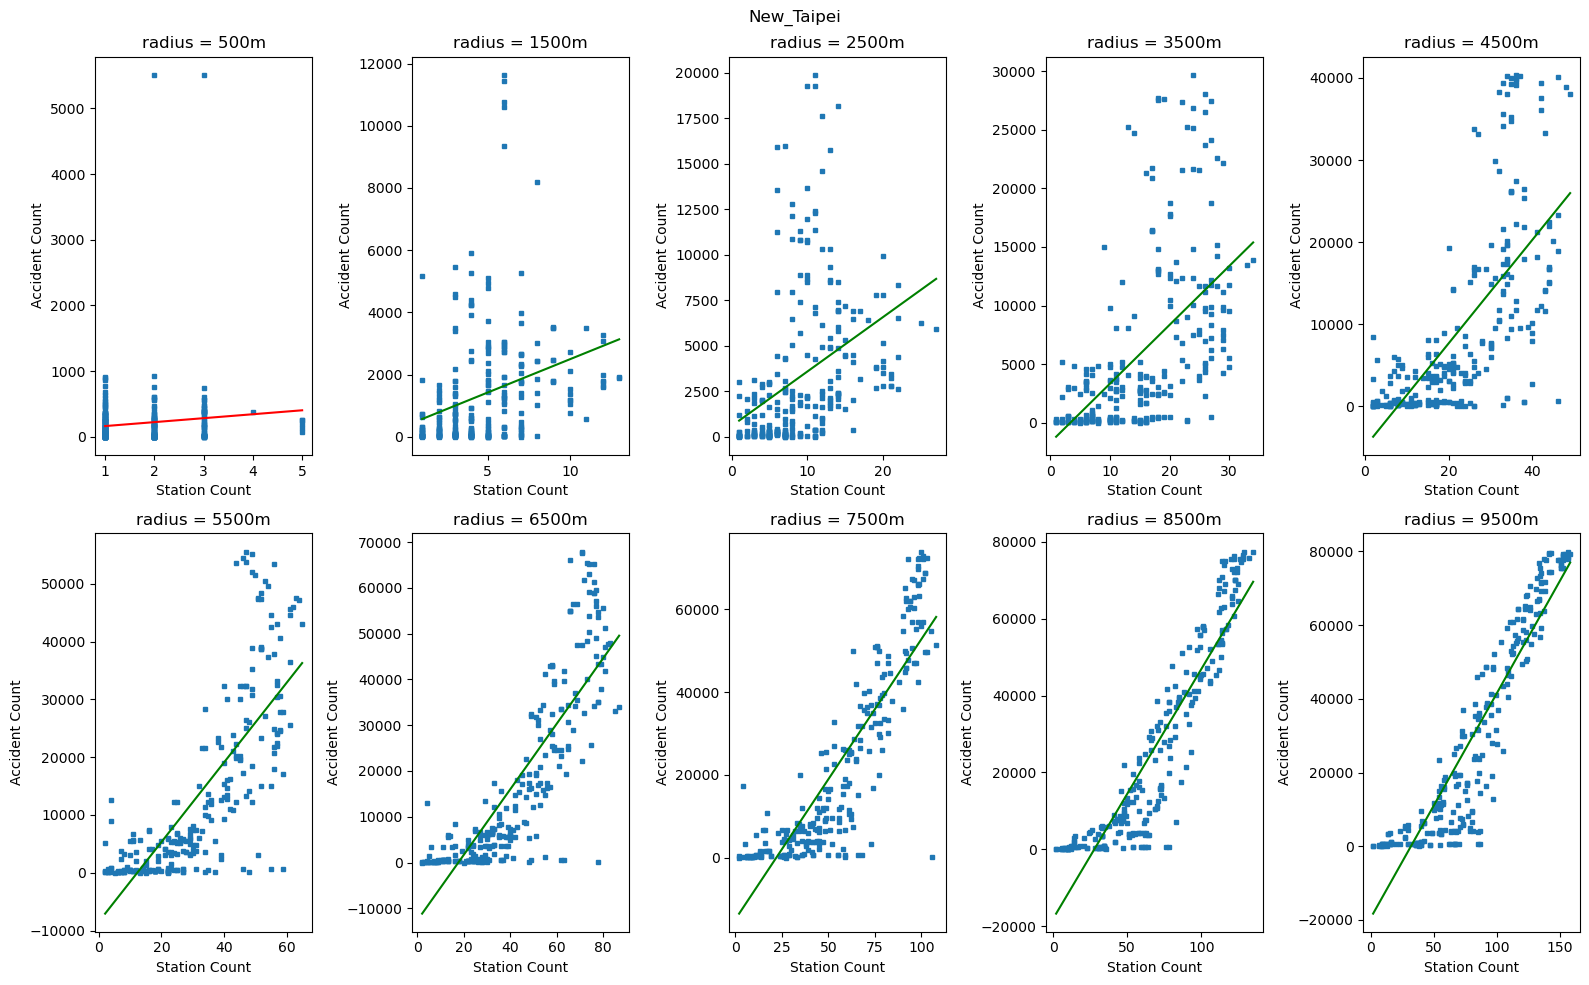

done


In [4]:
row_to_add = []
for j in ['臺北市', '新北市']: 
    fig, ax = plt.subplots(row,col, figsize = (16,10))
    # print(f'year = {j}')
    # print('=========================================')
    # print(accident.size)
    
    for i in radius:
        # print(f'radius = {i}m')
        # print('=========================================')
        filename = f'./{COUNTYNAME[j]}_count/113/{COUNTYNAME[j]}_count_{i}m.csv'
        file = pd.read_csv(filename, sep = ',', skipinitialspace=True)
        # print(i,'\n==========================================================================================')
        city_limit = gpd.GeoDataFrame(data = file,geometry=gpd.points_from_xy(file['Longitude'], file['Latitude']), crs="EPSG:4326")
        # print(city_limit.size)
        
        buffers = city_limit.copy()
        buffers = buffers.to_crs(epsg = 3826)
        buffers['geometry'] = buffers.buffer(i)
        
        joined = gpd.sjoin(accident, buffers, how="inner", predicate="within")
        # 6. 計算數量
        # index_right 代表是「哪一個圓(測站)」
        # 我們計算每個圓裡面有多少個點
        counts = joined.groupby('index_right',as_index=False).size()
        counts['size'] = counts['size']
        city_limit['Acc_Count'] = counts['size']
        city_limit['Acc_Count'] = city_limit['Acc_Count'].fillna(0)
        # 8. (選用) 填補 NaN (有些測站附近完全沒人，會變 NaN，補 0)
        city_limit['Station_Count'] = city_limit['Station_Count'].fillna(0)
    
        G = np.ones(len(city_limit))
        G = np.array([G, city_limit['Station_Count']]).T
        
        d = np.array([city_limit['Acc_Count']]).T
        mLS, RSS_LS, var_LS = utils.solveLS(G,d)
        tmp,H = corr(city_limit['Station_Count'],city_limit['Acc_Count'],i)
        row_to_add.append(tmp)
        x = np.linspace(city_limit['Station_Count'].min(), city_limit['Station_Count'].max(), 1000)
    
        # print(int(((i-min_radius)/gap)//col))
        # print(int(((i-min_radius)/gap)%col))
        try:
            ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].set_title(f'radius = {i}m')
            ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].set_xlabel('Station Count')
            ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].set_ylabel('Accident Count')
            ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].plot(city_limit['Station_Count'], city_limit['Acc_Count'], linestyle = '', marker = 's', markersize = 3)
            if H == True:
                ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].plot(x, mLS[0]+x*mLS[1], 'g-')
            elif H == False:
                ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].plot(x, mLS[0]+x*mLS[1], 'r-')
        except:
            fig, ax = plt.subplots(row,col)
            ax.set_title(f'radius = {i}m')
            ax.set_xlabel('Station Count')
            ax.set_ylabel('Accident Count')
            ax.plot(city_limit['Station_Count'], city_limit['Acc_Count'], linestyle = '', marker = 's')
            if H == True:
                ax.plot(x, mLS[0]+x*mLS[1], 'g-')
            elif H == False:
                ax.plot(x, mLS[0]+x*mLS[1], 'r-')
    # plt.legend()
    print('=================================================================================')
    fig.suptitle(f"{COUNTYNAME[j]}")
    plt.tight_layout()
    plt.show()
print('done')
correlation = pd.DataFrame(row_to_add, columns=['correlation_coefficient','p_value','rr'])

## 合併計算、計算相關係數差異性

Radius =  500
臺北市測速照相密度與事故發生密度相關性與新北市「無顯著差異」
Radius =  1500
臺北市測速照相密度與事故發生密度相關性與新北市「無顯著差異」
Radius =  2500
臺北市測速照相密度與事故發生密度相關性與新北市「無顯著差異」
Radius =  3500
臺北市測速照相密度與事故發生密度相關性與新北市「有顯著差異」
Radius =  4500
臺北市測速照相密度與事故發生密度相關性與新北市「有顯著差異」
Radius =  5500
臺北市測速照相密度與事故發生密度相關性與新北市「有顯著差異」
Radius =  6500
臺北市測速照相密度與事故發生密度相關性與新北市「無顯著差異」
Radius =  7500
臺北市測速照相密度與事故發生密度相關性與新北市「無顯著差異」
Radius =  8500
臺北市測速照相密度與事故發生密度相關性與新北市「無顯著差異」
Radius =  9500
臺北市測速照相密度與事故發生密度相關性與新北市「有顯著差異」


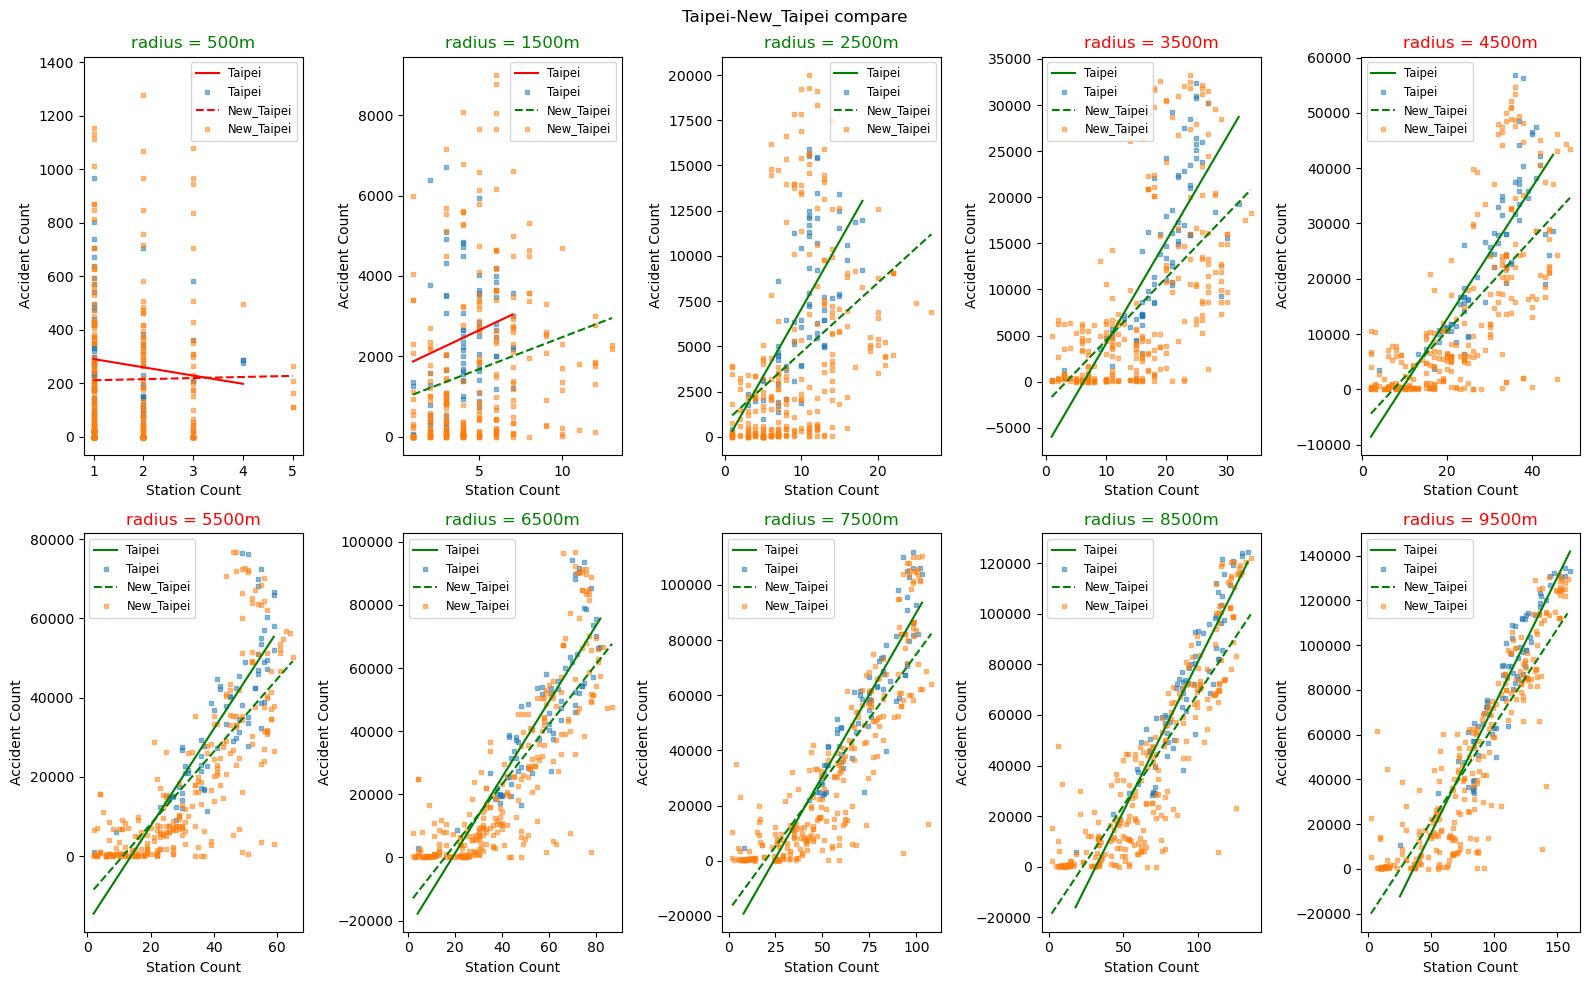

done


In [11]:
fig, ax = plt.subplots(row,col, figsize = (16,10))
for i in radius:
    tp= 0
    r = []
    n = []
    for j in COUNTY: 
        # print(f'radius = {i}m')
    # print('=========================================')
        filename = f'./{COUNTYNAME[j]}_count/113/{COUNTYNAME[j]}_count_{i}m.csv'
        file = pd.read_csv(filename, sep = ',', skipinitialspace=True)
        # print(i,'\n==========================================================================================')
        city_limit = gpd.GeoDataFrame(data = file,geometry=gpd.points_from_xy(file['Longitude'], file['Latitude']), crs="EPSG:4326")
        # print(city_limit.size)
        
        buffers = city_limit.copy()
        buffers = buffers.to_crs(epsg = 3826)
        buffers['geometry'] = buffers.buffer(i)
        n.append(len(city_limit))
        
       
        # print(f'year = {j}')
        # print('=========================================')
        # print(accident.size)
        
        joined = gpd.sjoin(accident, buffers, how="inner", predicate="within")
        # 6. 計算數量
        # index_right 代表是「哪一個圓(測站)」
        # 我們計算每個圓裡面有多少個點
        counts = joined.groupby('index_right',as_index=False).size()
        counts['size'] = counts['size']
        city_limit['Acc_Count'] = counts['size']
        city_limit['Acc_Count'] = city_limit['Acc_Count'].fillna(0)
        # 8. (選用) 填補 NaN (有些測站附近完全沒人，會變 NaN，補 0)
        city_limit['Station_Count'] = city_limit['Station_Count'].fillna(0)

        city_limit['ratio'] = city_limit['Acc_Count'].values/city_limit['Station_Count'].values
        
        G = np.ones(len(city_limit))
        G = np.array([G, city_limit['Station_Count']]).T
        
        d = np.array([city_limit['Acc_Count']]).T

        mLS, RSS_LS, var_LS = utils.solveLS(G,d)
        tmp,H = corr(city_limit['Station_Count'],city_limit['Acc_Count'],i)

        r.append(tmp[0])
        
        x = np.linspace(city_limit['Station_Count'].min(), city_limit['Station_Count'].max(), 100)
    
        # print(int(((i-min_radius)/gap)//col))
        # print(int(((i-min_radius)/gap)%col))
        try:
            if tp == 0:
                if H == True:
                    ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].plot(x, mLS[0]+x*mLS[1], 'g-', linewidth = 1.5, zorder = 2, label = COUNTYNAME[j])
                elif H == False:
                    ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].plot(x, mLS[0]+x*mLS[1], 'r-', linewidth = 1.5, zorder = 2, label = COUNTYNAME[j])
            else:
                if H == True:
                    ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].plot(x, mLS[0]+x*mLS[1], 'g--', linewidth = 1.5, zorder = 2, label = COUNTYNAME[j])
                elif H == False:
                    ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].plot(x, mLS[0]+x*mLS[1], 'r--', linewidth = 1.5, zorder = 2, label = COUNTYNAME[j])
            
    
            ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].set_xlabel('Station Count')
            ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].set_ylabel('Accident Count')
            ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].plot(city_limit['Station_Count'], city_limit['Acc_Count'], linestyle = '', marker = 's', markersize = 3, alpha = 0.5, zorder = 1, label = COUNTYNAME[j])
        except:
            if tp == 0:
                if H == True:
                    ax.plot(x, mLS[0]+x*mLS[1], 'g-', zorder = 2, label = COUNTYNAME[j])
                elif H == False:
                    ax.plot(x, mLS[0]+x*mLS[1], 'r-', zorder = 2, label = COUNTYNAME[j])
            else:
                if H == True:
                    ax.plot(x, mLS[0]+x*mLS[1], 'g--', zorder = 2, label = COUNTYNAME[j])
                elif H == False:
                    ax.plot(x, mLS[0]+x*mLS[1], 'r--', zorder = 2, label = COUNTYNAME[j])
            
    
            ax.set_xlabel('Station Count')
            ax.set_ylabel('Accident Count')
            ax.plot(city_limit['Station_Count'], city_limit['Acc_Count'], linestyle = '', marker = 's', markersize = 10,alpha = 0.5, zorder = 1, label = COUNTYNAME[j])
        
        tp +=1
    comp = compare_correlations(r1 = r[0],r2 = r[1],n1 = n[0],n2 = n[1])
    print('Radius = ', i)

    try:
        if comp < 0.05:
            print('臺北市測速照相密度與事故發生密度相關性與新北市「有顯著差異」')
            ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].set_title(f'radius = {i}m', color = 'r')
        else:
            print('臺北市測速照相密度與事故發生密度相關性與新北市「無顯著差異」')
            ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].set_title(f'radius = {i}m', color = 'g')
        ax[int(((i-min_radius)/gap)//col)][int(((i-min_radius)/gap)%col)].legend(fontsize = 'small')
    except:
        if comp < 0.05:
            print('臺北市測速照相密度與事故發生密度相關性與新北市「有顯著差異」')
            ax.set_title(f'radius = {i}m', color = 'r')
        else:
            print('臺北市測速照相密度與事故發生密度相關性與新北市「無顯著差異」')
            ax.set_title(f'radius = {i}m', color = 'g')
        ax.legend(fontsize = 'large')
    # plt.legend()
    print('=================================================================================')
fig.suptitle(f"{COUNTYNAME['臺北市']}-{COUNTYNAME['新北市']} compare")
plt.tight_layout()
plt.savefig('Taipei_NewTaipei_corr_compare.png', dpi = 300)
plt.show()
print('done')

In [6]:
correlation['radius'] = 500+correlation.index%len(radius)*gap
for i in range(2):
    if i == 0:
        print(correlation.iloc[correlation.loc[:len(correlation)/2-1]['correlation_coefficient'].idxmax()], end = '\n\n')
    else:
        print(correlation.iloc[correlation.loc[len(correlation)/2:]['correlation_coefficient'].idxmax()], end = '\n\n')
correlation

correlation_coefficient    6.861210e-01
p_value                    1.094874e-11
rr                         4.707620e-01
radius                     5.500000e+03
Name: 5, dtype: float64

correlation_coefficient     9.374141e-01
p_value                    1.503948e-127
rr                          8.787453e-01
radius                      9.500000e+03
Name: 19, dtype: float64



,correlation_coefficient,p_value,rr,radius
0,-0.097823,4.037467e-01,0.009569,500
1,0.229629,4.750024e-02,0.052729,1500
2,0.523371,1.451347e-06,0.273917,2500
3,0.596328,1.649584e-08,0.355607,3500
4,0.616641,3.852882e-09,0.380246,4500
5,0.686121,1.094874e-11,0.470762,5500
6,0.655281,1.783542e-10,0.429393,6500
7,0.565131,1.277129e-07,0.319373,7500
8,0.491313,7.612135e-06,0.241388,8500
9,0.481849,1.203509e-05,0.232178,9500
